# Versao 12 - Comparacao LSTM Profunda Hierarquica Multitarefa Vs Baselines

A `versao12` so faz sentido como experimento completo se for comparada, no mesmo protocolo, com as baselines tabulares e com as melhores LSTMs anteriores.

## O que este notebook responde

A comparacao final da `versao12` precisa responder tres perguntas:

1. a nova arquitetura melhora sobre as LSTMs anteriores?
2. ela reduz o gap para `RandomForest`, `XGBoost` e `LGBM`?
3. o ganho, se existir, veio da combinacao coerente dos blocos metodologicos ou apenas do aumento de complexidade?


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao12" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from versao12.pipeline_v12 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    fit_lgbm_baseline,
    fit_random_forest_baseline,
    fit_xgboost_baseline,
    load_bundle,
    load_multitask_temporal_model,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
    predict_multitask_model_classes,
)

RUN_NAME = "classificacao_v12_profunda_hierarquica_multitarefa"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v12" / RUN_NAME
LSTM_DIR = RUN_DIR / "lstm"
BASELINE_DIR = RUN_DIR / "baselines"

PREVIOUS_METRIC_FILES = {
    "LSTM v9": PROJECT_ROOT / "artifacts" / "reports_v9" / "classificacao_v9_lstm_hibrida" / "lstm" / "hybrid_lstm_test_metrics.json",
    "LSTM v10": PROJECT_ROOT / "artifacts" / "reports_v10" / "classificacao_v10_multitarefa" / "lstm" / "multitask_test_metrics.json",
    "LSTM v11": PROJECT_ROOT / "artifacts" / "reports_v11" / "classificacao_v11_foco_por_class_observacional" / "lstm" / "multitask_test_metrics.json",
}


In [2]:
bundle = load_bundle(RUN_DIR / "bundle_v12.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

multitask_model = load_multitask_temporal_model(LSTM_DIR / "hierarchical_multitask_temporal_config.json")
multitask_validation_pred = predict_multitask_model_classes(
    multitask_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
multitask_test_pred = predict_multitask_model_classes(
    multitask_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

multitask_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    multitask_validation_pred,
    class_labels=bundle.class_labels,
)
multitask_test_eval = evaluate_predictions(
    test_arrays["y"],
    multitask_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(multitask_validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(multitask_test_eval, LSTM_DIR, "multitask_test")


{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/multitask_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/multitask_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/multitask_test_predictions.npz'}

In [3]:
rf_model = fit_random_forest_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
    n_estimators=400,
)
rf_validation_pred = rf_model.predict(validation_arrays["X_tab"])
rf_test_pred = rf_model.predict(test_arrays["X_tab"])

rf_validation_eval = evaluate_predictions(
    validation_arrays["y"],
    rf_validation_pred,
    class_labels=bundle.class_labels,
)
rf_test_eval = evaluate_predictions(
    test_arrays["y"],
    rf_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(rf_validation_eval, BASELINE_DIR, "random_forest_validation")
export_evaluation_artifacts(rf_test_eval, BASELINE_DIR, "random_forest_test")


{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/baselines/random_forest_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/baselines/random_forest_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/baselines/random_forest_test_predictions.npz'}

In [4]:
xgb_model = fit_xgboost_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
)

if xgb_model is None:
    print("XGBoost nao esta disponivel neste ambiente.")
    xgb_validation_eval = None
    xgb_test_eval = None
else:
    xgb_validation_pred = xgb_model.predict(validation_arrays["X_tab"])
    xgb_test_pred = xgb_model.predict(test_arrays["X_tab"])

    xgb_validation_eval = evaluate_predictions(
        validation_arrays["y"],
        xgb_validation_pred,
        class_labels=bundle.class_labels,
    )
    xgb_test_eval = evaluate_predictions(
        test_arrays["y"],
        xgb_test_pred,
        class_labels=bundle.class_labels,
    )

    export_evaluation_artifacts(xgb_validation_eval, BASELINE_DIR, "xgboost_validation")
    export_evaluation_artifacts(xgb_test_eval, BASELINE_DIR, "xgboost_test")


In [5]:
lgbm_model = fit_lgbm_baseline(
    train_arrays["X_tab"],
    train_arrays["y"],
    random_state=42,
)

if lgbm_model is None:
    print("LightGBM nao esta disponivel neste ambiente.")
    lgbm_validation_eval = None
    lgbm_test_eval = None
else:
    lgbm_validation_pred = lgbm_model.predict(validation_arrays["X_tab"])
    lgbm_test_pred = lgbm_model.predict(test_arrays["X_tab"])

    lgbm_validation_eval = evaluate_predictions(
        validation_arrays["y"],
        lgbm_validation_pred,
        class_labels=bundle.class_labels,
    )
    lgbm_test_eval = evaluate_predictions(
        test_arrays["y"],
        lgbm_test_pred,
        class_labels=bundle.class_labels,
    )

    export_evaluation_artifacts(lgbm_validation_eval, BASELINE_DIR, "lgbm_validation")
    export_evaluation_artifacts(lgbm_test_eval, BASELINE_DIR, "lgbm_test")


/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
metrics_by_model = {
    "LSTM v12": {
        "accuracy": multitask_test_eval["accuracy"],
        "macro_f1": multitask_test_eval["macro_f1"],
        "balanced_accuracy": multitask_test_eval["balanced_accuracy"],
    },
    "RandomForest": {
        "accuracy": rf_test_eval["accuracy"],
        "macro_f1": rf_test_eval["macro_f1"],
        "balanced_accuracy": rf_test_eval["balanced_accuracy"],
    },
}

if xgb_test_eval is not None:
    metrics_by_model["XGBoost"] = {
        "accuracy": xgb_test_eval["accuracy"],
        "macro_f1": xgb_test_eval["macro_f1"],
        "balanced_accuracy": xgb_test_eval["balanced_accuracy"],
    }

if lgbm_test_eval is not None:
    metrics_by_model["LGBM"] = {
        "accuracy": lgbm_test_eval["accuracy"],
        "macro_f1": lgbm_test_eval["macro_f1"],
        "balanced_accuracy": lgbm_test_eval["balanced_accuracy"],
    }

for model_name, metrics_path in PREVIOUS_METRIC_FILES.items():
    if metrics_path.exists():
        payload = json.loads(metrics_path.read_text(encoding="utf-8"))
        metrics_by_model[model_name] = {
            "accuracy": payload["accuracy"],
            "macro_f1": payload["macro_f1"],
            "balanced_accuracy": payload["balanced_accuracy"],
        }

comparison_df = build_metrics_table(metrics_by_model)
display(comparison_df.sort_values("macro_f1", ascending=False).reset_index(drop=True))


,modelo,accuracy,macro_f1,balanced_accuracy
0,XGBoost,0.982090,0.985757,0.985681
1,LGBM,0.982090,0.981537,0.973318
2,RandomForest,0.985075,0.981135,0.974442
3,LSTM v10,0.937313,0.940859,0.957198
4,LSTM v12,0.943284,0.929828,0.956111
5,LSTM v9,0.922388,0.926817,0.941495
6,LSTM v11,0.919403,0.911840,0.923831


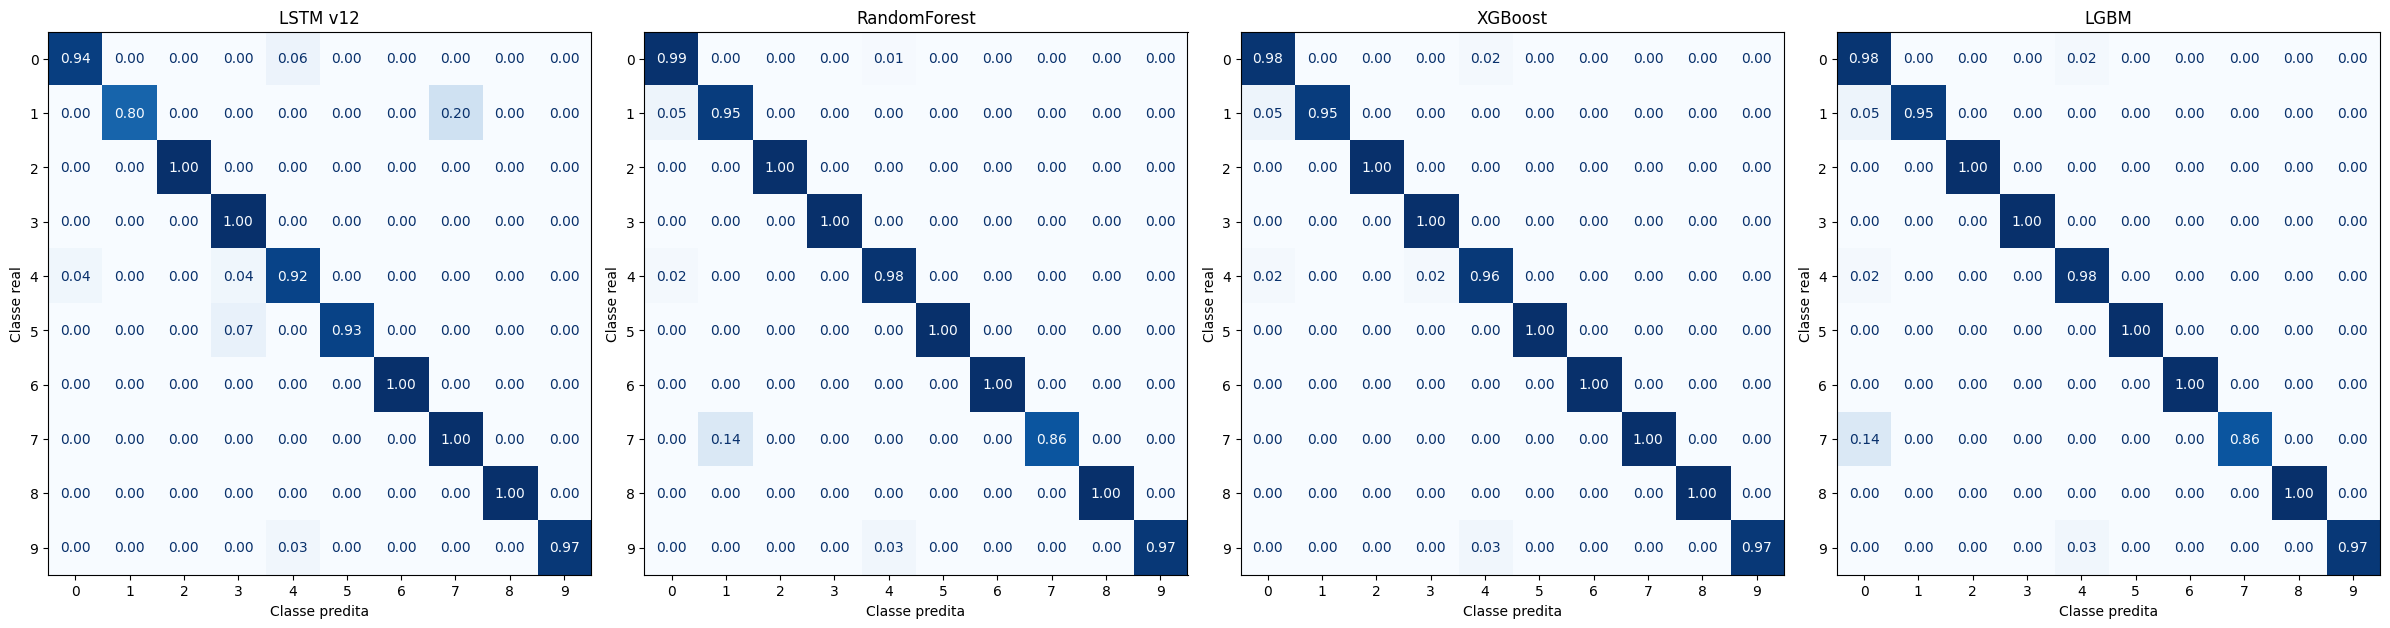

In [7]:
model_specs = [
    ("LSTM v12", multitask_test_pred),
    ("RandomForest", rf_test_pred),
]
if xgb_test_eval is not None:
    model_specs.append(("XGBoost", xgb_test_pred))
if lgbm_test_eval is not None:
    model_specs.append(("LGBM", lgbm_test_pred))

fig, axes = plt.subplots(1, len(model_specs), figsize=(6 * len(model_specs), 6))
if len(model_specs) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, model_specs):
    plot_confusion_matrix_for_predictions(
        test_arrays["y"],
        y_pred,
        bundle.class_labels,
        normalize="true",
        title=model_name,
        ax=ax,
    )

plt.tight_layout()
plt.show()


## Como interpretar este notebook

A `versao12` deve ser lida com o mesmo rigor aplicado as versoes anteriores. Se ela melhorar, a leitura metodologica sera que a combinacao dos blocos fez sentido. Se ela piorar ou empatar, isso tambem sera um resultado importante: indicara que parte da complexidade adicionada nao se converteu em ganho real frente a uma baseline tabular ainda muito forte.